# 107_06 — PSBPM-FD contra el FAR · Escenario C-1 · **barrido en $M$**

Paso **3d**. Lo mismo que `107_05`, restringido a los dos modelos con mecanismo
de intervalo propio —**FAR(p)** y **PSBPM-FD**— y en versión resumida: mismas
diez métricas, misma ventana móvil, mismos objetivos de evaluación. No hay RF,
GBT ni líneas base.

| Sección | Qué responde |
|---|---|
| 1 | imports, configuración, artefactos y validaciones |
| 2 | FAR(p) sobre los coeficientes B-spline y predicción puntual del PSBPM-FD |
| 3 | **Bloque A** (métricas 1-4): resumen mín/máx/promedio, ventanas ganadas, figuras |
| 4 | **Bloque B** (métricas 5-10): tres bandas, dos objetivos, resumen y figuras |
| 5 | curvas mejor y peor predichas con las dos bandas superpuestas (un solo $M$) |

Lee `banda_funcional_psbp.npz` que persiste `107_04`: ese notebook debe haber
corrido para todo el barrido.

## 1. Imports, configuración y artefactos

In [9]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_psbp_fd.pipelines import (
    cargar_curvas, cargar_representacion, cargar_fpca, cargar_estandarizador,
    cargar_datasets_ar, cargar_hiperparametros, cargar_config_evaluacion,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.models.pspb_fd_v3 import (
    ruta_traza, ModeloTraza, curva_media_desde_scores,
)
from model_psbp_fd.fit import (
    mise, ventana_movil_funcional, normas_error_por_origen,
    residuos_para_banda, banda_predictiva_modelo,
    resumen_intervalo, indicador_cobertura_simultanea,
)
from model_psbp_fd.fit.far_operador import FARp, seleccionar_kn
from model_psbp_fd.graphics import plot_ventana_movil
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.utils.linalg import safe_chol

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [10]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG]
BASENAME, ESCENARIO_ID, REPLICA_ID = "escenario_107_v2", 1, 1
M_FPCA_LIST = (1, 2, 3, 4, 5, 6)
M_DETALLE = 4                    # punto del barrido para §5

METRICAS_A = [
    (u"1. MAE  (L^1)",                 "mae_f"),
    (u"2. RMSE (L^2)",                 "rmse_f"),
    (u"3. E_max promedio por curva",   "linf_medio"),
    (u"4. E_max peor de la ventana",   "linf_max"),
]
METRICAS_B = [
    (u"5. MPIW",                       "mpiw"),
    (u"6. PICP puntual",               "picp"),
    (u"7. PICPB curva completa",       "picp_simultaneo"),
    (u"8. Winkler",                    "winkler"),
    (u"9. Winkler max promedio",       "winkler_max_medio"),
    (u"10. Winkler max peor ventana",  "winkler_max_glob"),
]
METRICAS_A_COLS = [c for _, c in METRICAS_A]
METRICAS_B_COLS = [c for _, c in METRICAS_B]

NIVEL_IC = 0.95                  # igual al `nivel_credibilidad` del _04
IC_POR_TAU = True
IC_CORRECCION_ESTIMACION = True
KN_MAX, CRITERIO_KN = 12, "L2"
METRICA_SEL_IC, N_EXTREMOS = "rmse_f", 5
PESOS_TAU = None

ESTILOS_VENTANA = {
    "FAR":      dict(color="#1f6f8b", lw=3.0, ls="--"),
    "PSBPM-FD": dict(color="#c0392b", lw=1.6, ls="-", zorder=5),
}

M_FPCA_LIST = tuple(int(m) for m in M_FPCA_LIST)
EXPERIMENT_BASE = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"


def experiment_id(M: int) -> str:
    return f"{EXPERIMENT_BASE}_m{M:02d}"


def rutas(M: int) -> dict:
    eid = experiment_id(M)
    p = {
        "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / eid,
        "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / eid,
        "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / eid,
        "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / eid,
        "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / eid,
    }
    for r in p.values():
        r.mkdir(parents=True, exist_ok=True)
    return p


PATHS_M = {M: rutas(M) for M in M_FPCA_LIST}
PATH_BARRIDO = PROJECT_ROOT / "reports" / "simulaciones" / f"{EXPERIMENT_BASE}_barrido_M"
PATH_BARRIDO.mkdir(parents=True, exist_ok=True)

# Por M: 120-124. Barrido: 126-127. No pisa lo del _04 (5x, 6x, 9x) ni el _05 (7x, 8x, 9x).
PREFIJO = 120
print(f"barrido en M : {list(M_FPCA_LIST)}   ·   detalle §5 en M={M_DETALLE}")

barrido en M : [1, 2, 3, 4, 5, 6]   ·   detalle §5 en M=4


In [11]:
EST, saltados = {}, []

for M in M_FPCA_LIST:
    P = PATHS_M[M]
    if not (P["functional"] / "datasets_manifest.json").exists():
        saltados.append(M)
        continue

    dfs_train, manifest = cargar_datasets_ar(P, bloque="train")
    dfs_test,  _        = cargar_datasets_ar(P, bloque="test")
    hp_json     = cargar_hiperparametros(P)
    P["trazas"] = P["out_artefact"].parent / hp_json.get("trazas_en", P["out_artefact"].name)
    eval_config = cargar_config_evaluacion(P)

    component_idx = manifest["component_idx"]
    assert len(component_idx) == M, f"[M={M}] el manifest tiene {len(component_idx)} componentes."
    assert manifest["scores_scale"] == "raw_fpca_scores"
    objetivo = eval_config.get("objetivo_evaluacion", "curva_suavizada")
    assert objetivo == "curva_suavizada", (
        f"[M={M}] objetivo_evaluacion={objetivo!r}: las cifras no serían las del _04.")

    EST[M] = {
        "paths": P, "eid": experiment_id(M),
        "dfs_train": dfs_train, "dfs_test": dfs_test, "manifest": manifest,
        "hp_json": hp_json, "eval_config": eval_config,
        "component_idx": component_idx, "n_components": M,
        "cov_por_componente": [list(manifest["cov_por_componente"][str(k)]) for k in range(M)],
        "n_lags": int(manifest["n_lags"]),
        "T": int(manifest["T"]), "T0": int(manifest["T0"]),
        "n_iter": int(hp_json["n_iter"]),
        "objetivo": objetivo,
        "modo_residuo": eval_config.get("modo_residuo", "ninguno"),
        "ventanas_w": list(eval_config.get("ventana_movil", {}).get("w", [20, 30, 40])),
    }

assert EST, "Ningún punto del barrido tiene datos. Ejecuta 107_01 primero."
if saltados:
    print(f"! sin artefactos de 107_01, saltados: M={saltados}")

_comun = {M: (e["T"], e["T0"], e["n_lags"], e["objetivo"], e["modo_residuo"],
              tuple(e["ventanas_w"])) for M, e in EST.items()}
assert len(set(_comun.values())) == 1, f"Los puntos no comparten diseño: {_comun}"

_M0 = next(iter(EST))
T, T0, N_LAGS = EST[_M0]["T"], EST[_M0]["T0"], EST[_M0]["n_lags"]
VENTANAS_W = EST[_M0]["ventanas_w"]
W_COMP = VENTANAS_W[len(VENTANAS_W) // 2]
print(f"T={T}  T0={T0}  n_lags={N_LAGS}  objetivo='curva_suavizada'  "
      f"anchos={VENTANAS_W}  w de referencia={W_COMP}")

T=1000  T0=700  n_lags=2  objetivo='curva_suavizada'  anchos=[20, 30, 40]  w de referencia=30


In [12]:
for M in EST:
    e, P = EST[M], EST[M]["paths"]
    fpca = cargar_fpca(P)
    assert fpca.verificar()["todo_ok"], f"[M={M}] las identidades FPCA no se cumplen."
    std = cargar_estandarizador(P, DataStandardizer)
    fr_M, THETA_M, _ = cargar_representacion(P)
    assert e["component_idx"] == list(range(fpca.M))
    assert std.n_ajuste == T0, f"[M={M}] estandarizador ajustado con n={std.n_ajuste} != T0={T0}."
    e.update({"fpca": fpca, "std": std, "fr": fr_M, "THETA": np.asarray(THETA_M, dtype=float),
              "SCORES": fpca.SCORES})

for M in EST:
    assert np.allclose(EST[M]["THETA"], EST[_M0]["THETA"]), \
        f"[M={M}] la representación B-spline difiere de la de M={_M0}."

fr0    = EST[_M0]["fr"]
THETA0 = EST[_M0]["THETA"]
X_suav = fr0.reconstruct(THETA0)                  # (T, G) objetivo: curva suavizada
_, grilla = cargar_curvas(EST[_M0]["paths"])

t_orig  = np.arange(N_LAGS + 1, T + 1)
n_orig  = len(t_orig)
T0_orig = T0 - N_LAGS
es_train = t_orig <= T0
X_obj_ev = X_suav[N_LAGS:]

for M in EST:
    e = EST[M]
    dfs_full = {k: pd.concat([e["dfs_train"][k], e["dfs_test"][k]], ignore_index=True)
                for k in range(M)}
    assert len(dfs_full[0]) == n_orig
    e["dfs_full"] = dfs_full
    e["Y_obs"] = np.column_stack([dfs_full[k].iloc[:, 0].to_numpy(dtype=float) for k in range(M)])
    e["curvas_desde_scores_std"] = (
        lambda Y, e=e: curva_media_desde_scores(Y, e["fpca"], e["std"]))
    e["X_proj"] = e["fpca"].reconstruct(e["SCORES"])[N_LAGS:]
    assert np.allclose(e["curvas_desde_scores_std"](e["Y_obs"]), e["X_proj"], atol=1e-8), \
        f"[M={M}] el mapa scores->curva no reproduce la proyección FPCA."

print(f"orígenes {n_orig}  (train {es_train.sum()} · test {(~es_train).sum()})   ·   "
      f"grilla {grilla.shape}   ·   K={THETA0.shape[1]}")

orígenes 998  (train 698 · test 300)   ·   grilla (75,)   ·   K=14


## 2. Los dos modelos

**FAR(p), $p=$ `N_LAGS`**, sobre los coeficientes B-spline y en la métrica $L^2$:
se blanquea con la Cholesky de la Gram ($W=LL^\top$) para que el producto
escalar euclídeo de los coeficientes sea el producto interno $L^2$. Se evalúa
con los $K$ coeficientes completos, sin truncar a $M$.

**PSBPM-FD**: media predictiva por score desde las trazas, propagada a la curva.

In [13]:
W_GRAM  = np.asarray(fr0.gram_, dtype=float)
L_GRAM  = safe_chol(W_GRAM)
THETA_W = THETA0 @ L_GRAM

_n_gram = np.einsum("tk,kl,tl->t", THETA0, W_GRAM, THETA0)
_err = float(np.max(np.abs(_n_gram - (THETA_W ** 2).sum(axis=1))) / np.max(_n_gram))
assert _err < 1e-8, f"El blanqueo no preserva la norma L^2 (error relativo {_err:.2e})."

_KN_TOPE = int(min(KN_MAX, THETA_W.shape[1]))
CV_KN = seleccionar_kn(THETA_W[:T0], kn_max=_KN_TOPE, pesos="conteo", p=N_LAGS)
KN_ELEGIDO = {"L1": CV_KN.kn_L1, "L2": CV_KN.kn_L2, "Linf": CV_KN.kn_Linf}[CRITERIO_KN]

FAR_MOD = FARp(p=N_LAGS, kn=KN_ELEGIDO, pesos="conteo").fit(THETA_W[:T0])
_diag = FAR_MOD.diagnostico_kn()

_THETA_W_pred = FAR_MOD.predict_serie(THETA_W)
assert _THETA_W_pred.shape[0] == n_orig, (_THETA_W_pred.shape, n_orig)
THETA_PRED_FAR = np.linalg.solve(L_GRAM.T, _THETA_W_pred.T).T
X_PRED_FAR = fr0.reconstruct(THETA_PRED_FAR)                  # (n_orig, G)

FAR_HS = float(np.sqrt(np.sum(np.asarray(_diag["norma_hs_por_rezago"]) ** 2)))
print(f"FAR(p={N_LAGS})  kn={KN_ELEGIDO} ({CRITERIO_KN})  K={THETA0.shape[1]}  "
      f"||rho||_HS={FAR_HS:.4f}  radio espectral={_diag['radio_espectral']:.4f}"
      + ("   <- >= 1: no estacionario" if _diag["radio_espectral"] >= 1 else ""))

FAR(p=2)  kn=5 (L2)  K=14  ||rho||_HS=1.0540  radio espectral=0.8453


In [14]:
_CACHE_MEDIA = {}
sin_trazas = []

for M in list(EST):
    e, P = EST[M], EST[M]["paths"]
    ci, n_iter = e["component_idx"], e["n_iter"]
    faltan = [ruta_traza(P, ci[k] + 1, c + 1).name for k in range(M) for c in range(n_iter)
              if not ruta_traza(P, ci[k] + 1, c + 1).exists()]
    npz_path = P["predict"] / "banda_funcional_psbp.npz"
    if faltan or not npz_path.exists():
        sin_trazas.append(M)
        print(f"! M={M} saltado: " + (f"faltan {len(faltan)} trazas" if faltan else "falta banda_funcional_psbp.npz (correr 107_04)"))
        del EST[M]
        continue

    Y_hat = np.empty_like(e["Y_obs"])
    for k in range(M):
        cov_k = e["cov_por_componente"][k]
        df_dis = pd.concat([pd.DataFrame({"_y": np.zeros(len(e["dfs_full"][k]))}),
                            e["dfs_full"][k][cov_k].reset_index(drop=True)], axis=1)
        medias = []
        for c in range(n_iter):
            if (M, ci[k], c) not in _CACHE_MEDIA:
                modelo = ModeloTraza.desde_ruta(ruta_traza(P, ci[k] + 1, c + 1))
                assert modelo.feature_names_ == cov_k, (
                    f"[M={M} k={k} c={c+1}] feature_names={modelo.feature_names_} != {cov_k}")
                _CACHE_MEDIA[(M, ci[k], c)] = modelo.momentos(df_dis)["media"]
            medias.append(_CACHE_MEDIA[(M, ci[k], c)])
        Y_hat[:, k] = np.column_stack(medias).mean(axis=1)
    e["X_pred_psbp"] = e["curvas_desde_scores_std"](Y_hat)

    z = np.load(npz_path, allow_pickle=False)
    m04 = mise(X_obj_ev[~es_train], z["X_pred"][~es_train], grilla)
    m06 = mise(X_obj_ev[~es_train], e["X_pred_psbp"][~es_train], grilla)
    dif = abs(m06 - m04) / m04
    print(f"M={M}: MISE test  _04={m04:.6f}  aquí={m06:.6f}  dif rel={dif:.2e}"
          + ("   ! sobre 1%: subir S_FUNC en el _04" if dif >= 0.01 else ""))
    assert dif < 0.05, f"[M={M}] el MISE difiere del _04 en {dif:.1%}: ¿otra configuración?"

assert EST, "Ningún punto tiene trazas y banda del _04."

M=1: MISE test  _04=0.910982  aquí=0.911343  dif rel=3.96e-04
M=2: MISE test  _04=0.806564  aquí=0.805971  dif rel=7.35e-04
M=3: MISE test  _04=0.793493  aquí=0.792843  dif rel=8.19e-04
M=4: MISE test  _04=0.789929  aquí=0.788880  dif rel=1.33e-03
M=5: MISE test  _04=0.785268  aquí=0.783974  dif rel=1.65e-03
M=6: MISE test  _04=0.783994  aquí=0.782789  dif rel=1.54e-03


## 3. Bloque A: error puntual (métricas 1-4)

Ventana móvil sobre la serie de orígenes, contra la curva suavizada. Todo agregado
excluye las ventanas que cruzan $T_0$. Para cada métrica: mínimo, máximo y promedio
de la serie de ventanas, y el % de ventanas en que cada modelo tiene el valor más bajo.

In [15]:
def resumen_ventana(limpio, col_grupo, metricas, M):
    # Una fila por (métrica, bloque, grupo): mín/máx/promedio sobre las ventanas y
    # % de ventanas ganadas. En picp gana el más cercano al nominal.
    filas = []
    for etq, col in metricas:
        piv = limpio.pivot_table(index=["t_centro", "bloque"], columns=col_grupo, values=col)
        obj = (piv - NIVEL_IC).abs() if col.startswith("picp") else piv
        gan = obj.idxmin(axis=1)
        for bloque in ("train", "test"):
            sel = piv.index.get_level_values("bloque") == bloque
            for g in piv.columns:
                x = piv.loc[sel, g]
                filas.append({"M": M, "metrica": etq, "columna": col, "bloque": bloque,
                              col_grupo: g, "minimo": x.min(), "maximo": x.max(),
                              "promedio": x.mean(), "pct_ganadas": float((gan[sel] == g).mean()),
                              "n_ventanas": int(sel.sum())})
    return filas


def vista_test(r, col_grupo, ratio=None):
    # Tabla ancha del TEST: por modelo, promedio / mínimo / máximo / % ganadas.
    t = r[r.bloque == "test"]
    grupos = list(dict.fromkeys(t[col_grupo]))
    stats = ["promedio", "minimo", "maximo", "pct_ganadas"]
    w = t.pivot_table(index=["M", "metrica"], columns=col_grupo, values=stats, sort=False)
    w = w[[(s, g) for g in grupos for s in stats]]
    if ratio:
        a, b = ratio
        w[("razon", f"{a}/{b}")] = w[("promedio", a)] / w[("promedio", b)]
    return w


def estilo_vista(w):
    fmt = {c: ("{:.1%}" if c[0] == "pct_ganadas" else "{:.4f}") for c in w.columns}
    return w.style.format(fmt, na_rep="-")

In [16]:
def tabla_ventana(M, w):
    e = EST[M]
    partes = []
    for nom, X_mod in (("FAR", X_PRED_FAR), ("PSBPM-FD", e["X_pred_psbp"])):
        t_ = ventana_movil_funcional(X_obj_ev, X_mod, grilla, T0_orig, w=w, t_offset=N_LAGS,
                                     pesos_tau=PESOS_TAU, bloque_A=True, verbose=False)
        t_["modelo"] = nom
        partes.append(t_)
    out = pd.concat(partes, ignore_index=True)
    out.attrs["w"] = w
    return out


filas_A = []
for M in EST:
    e = EST[M]
    e["tablas_w"] = {}
    for w in VENTANAS_W:
        e["tablas_w"][w] = tabla_ventana(M, w)
        e["tablas_w"][w].to_csv(e["paths"]["out_report"] / f"{PREFIJO}_ventana_far_psbp_w{w}.csv",
                                index=False)
    tw = e["tablas_w"][W_COMP]
    limpio = tw[~tw["cruza_T0"]]

    sub = limpio.dropna(subset=METRICAS_A_COLS)
    tol = 1e-9
    assert (sub["mae_f"] <= sub["l2_medio"] + tol).all(), f"[M={M}] mae_f > l2_medio"
    assert (sub["l2_medio"] <= sub["linf_medio"] + tol).all(), f"[M={M}] l2_medio > linf_medio"
    assert (sub["linf_medio"] <= sub["linf_max"] + tol).all(), f"[M={M}] linf_medio > linf_max"
    assert (sub["l2_medio"] <= sub["rmse_f"] + tol).all(), f"[M={M}] l2_medio > rmse_f (Jensen)"
    filas_A += resumen_ventana(limpio, "modelo", METRICAS_A, M)

resumen_A = pd.DataFrame(filas_A)
resumen_A.to_csv(PATH_BARRIDO / f"{PREFIJO + 6}_resumen_bloqueA.csv", index=False)

display(estilo_vista(vista_test(resumen_A, "modelo", ratio=("PSBPM-FD", "FAR")))
        .set_caption(f"Bloque A · TEST · sobre las ventanas (w={W_COMP}, sin cruzar T0) · "
                     "razón < 1: gana el PSBPM-FD"))

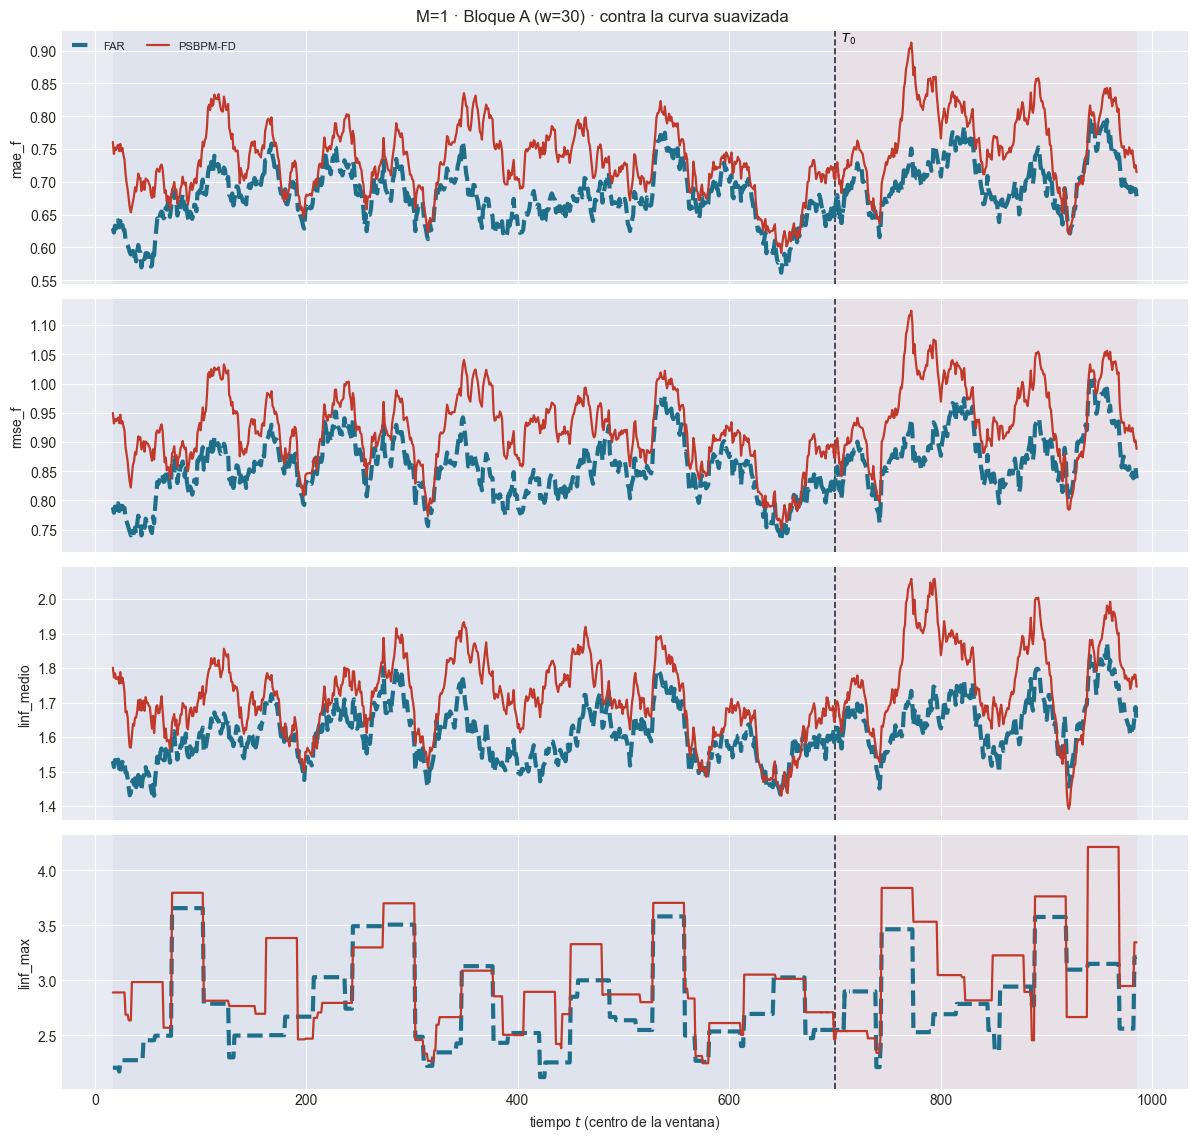

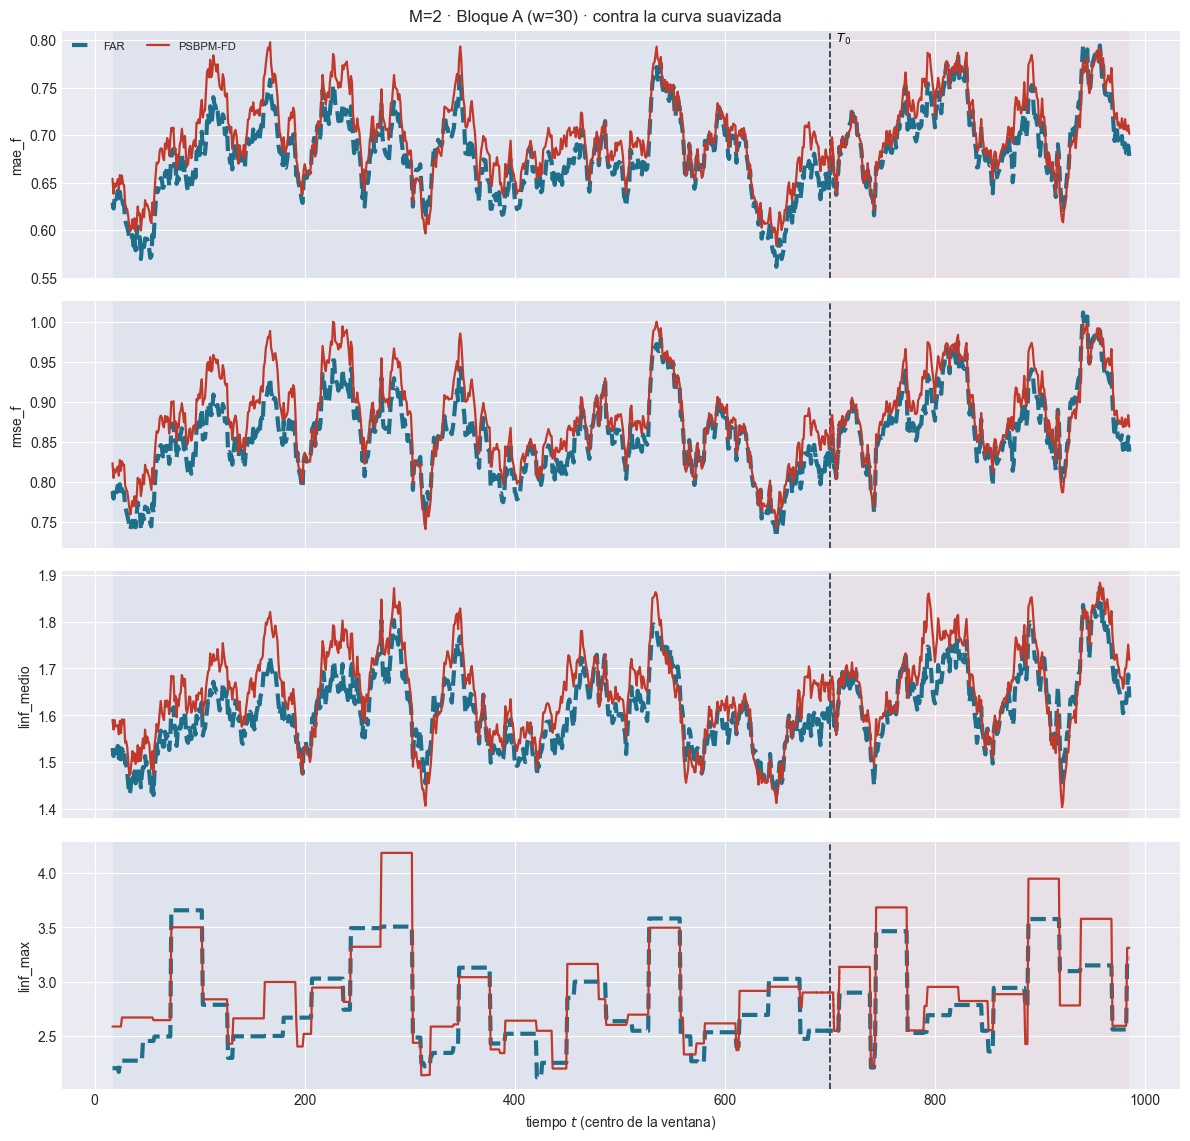

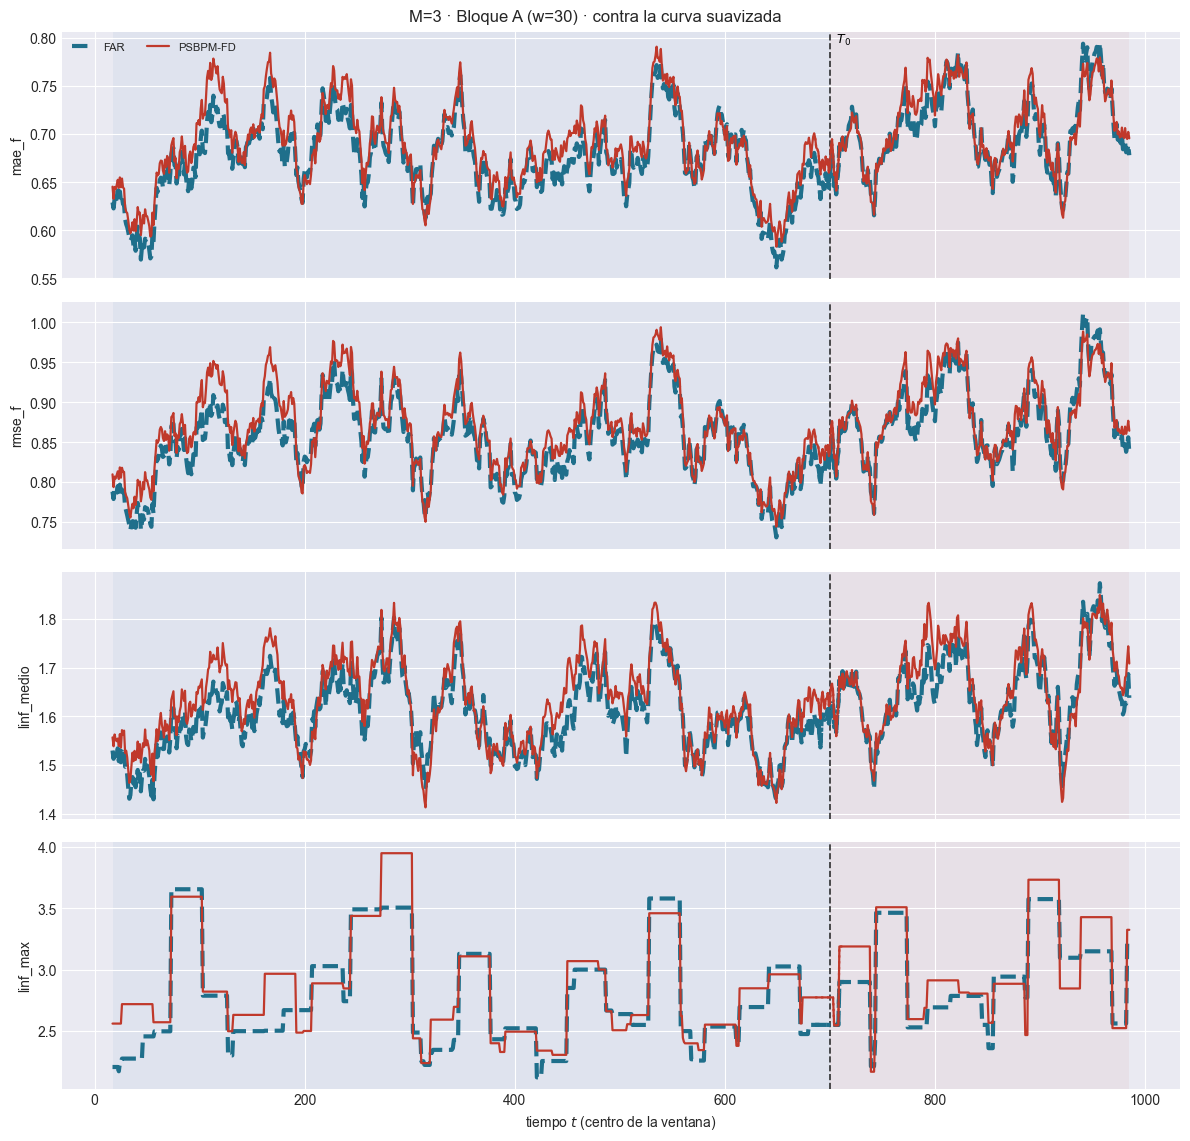

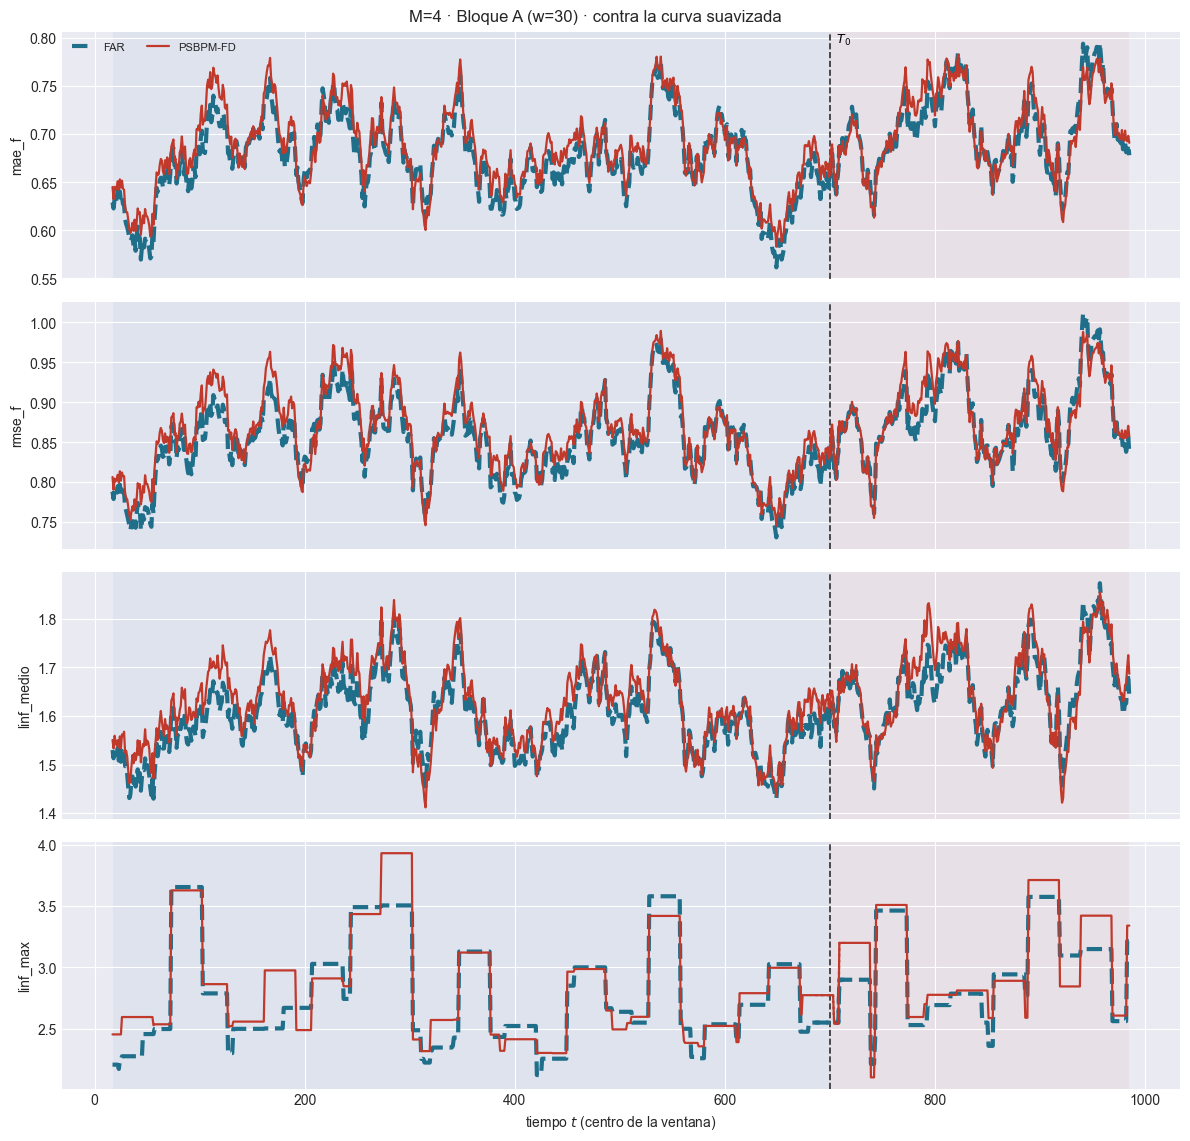

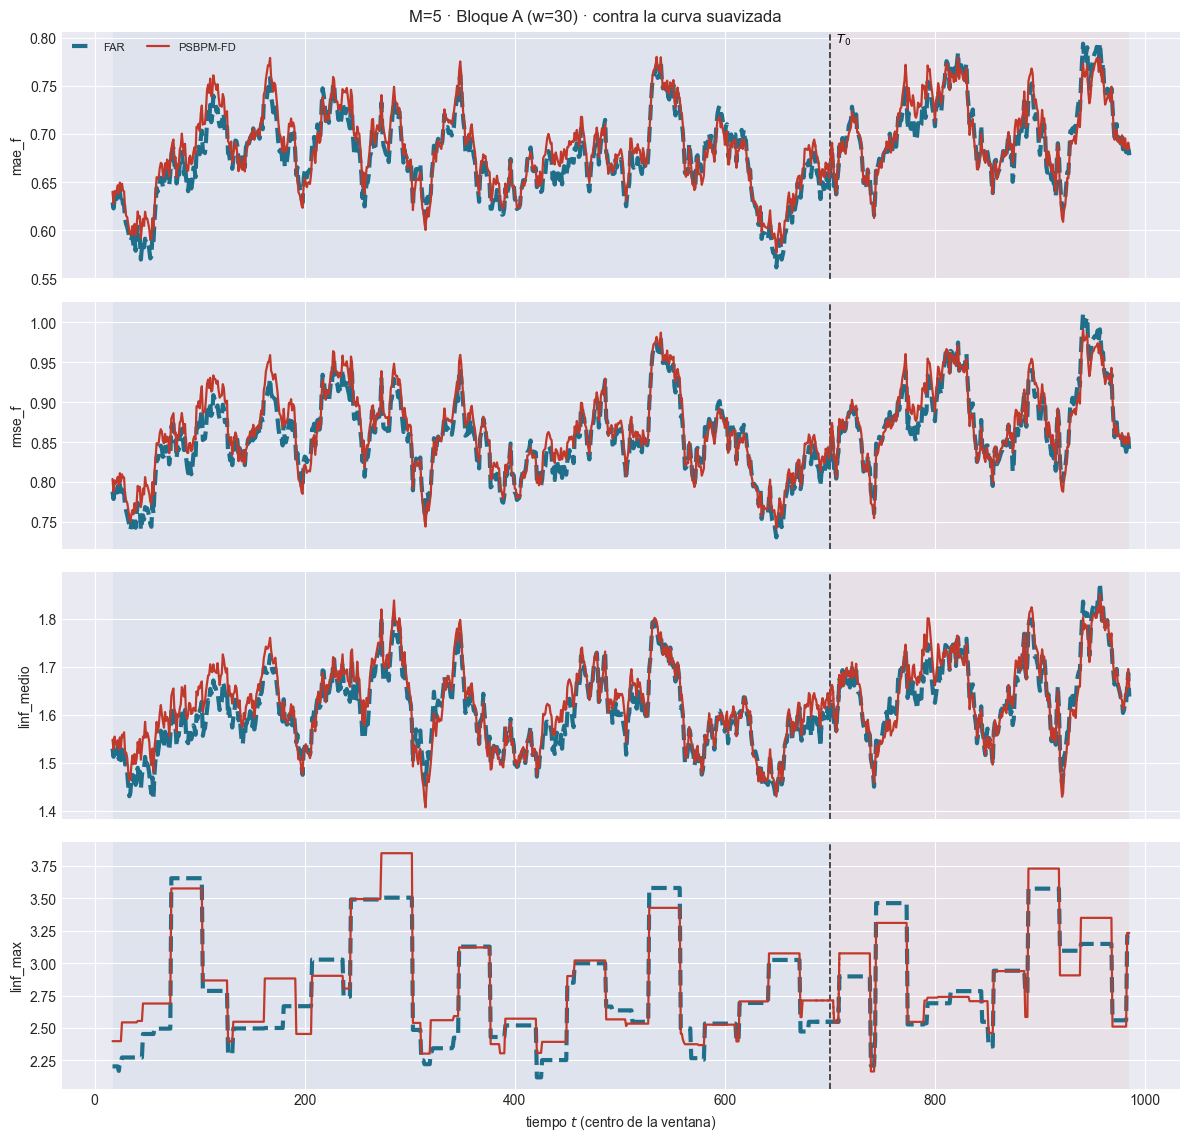

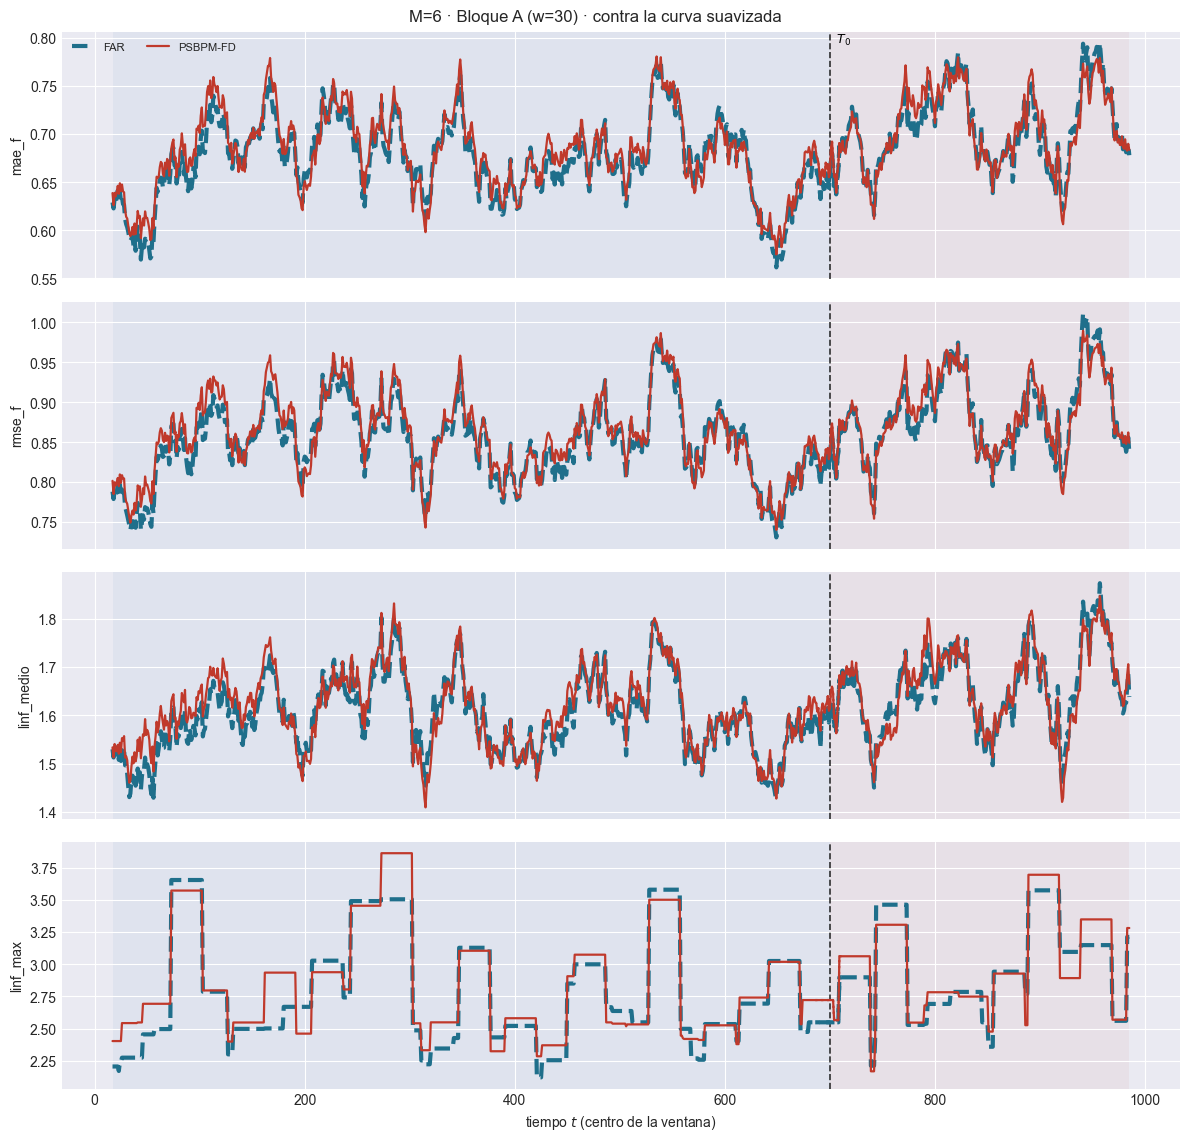

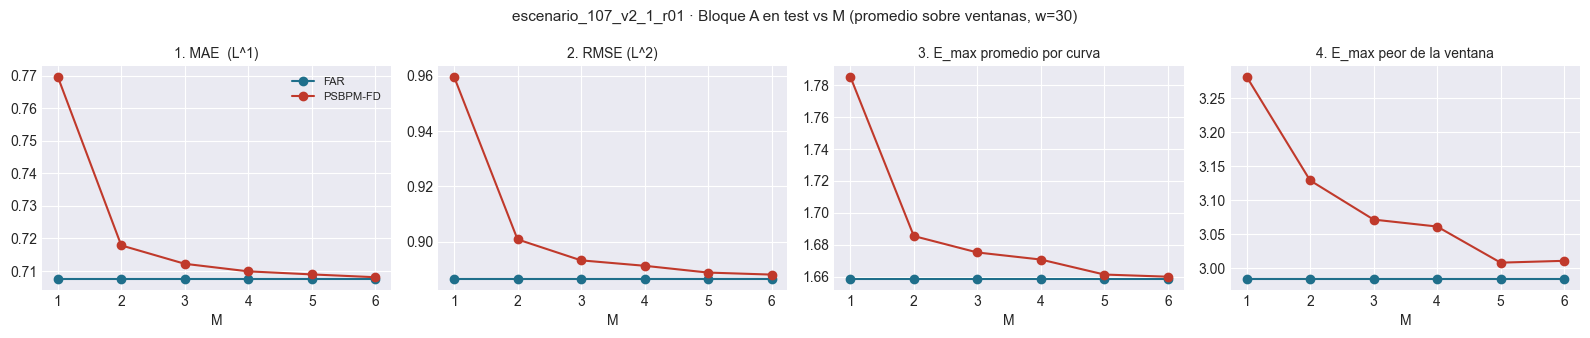

In [17]:
# Ventana móvil del Bloque A, una figura por M.
for M in EST:
    e = EST[M]
    plot_ventana_movil(
        e["tablas_w"][W_COMP], T0, METRICAS_A_COLS, columna_grupo="modelo",
        estilos=ESTILOS_VENTANA,
        title=f"M={M} · Bloque A (w={W_COMP}) · contra la curva suavizada",
        save_path=str(e["paths"]["out_report"] / f"{PREFIJO + 3}_ventana_bloqueA_w{W_COMP}.png"),
        verbose=False)
    plt.show()

# Barrido en M: promedio en test.
prom = (resumen_A[resumen_A.bloque == "test"]
        .pivot_table(index="M", columns=["columna", "modelo"], values="promedio"))
fig, axes = plt.subplots(1, len(METRICAS_A), figsize=(4.0 * len(METRICAS_A), 3.4), squeeze=False)
for ax, (etq, col) in zip(axes[0], METRICAS_A):
    for nom, est in ESTILOS_VENTANA.items():
        ax.plot(prom.index, prom[(col, nom)], "o-", color=est["color"], label=nom)
    ax.set_xticks(list(prom.index)); ax.set_xlabel("M"); ax.set_title(etq, fontsize=10)
axes[0][0].legend(fontsize=8)
fig.suptitle(f"{EXPERIMENT_BASE} · Bloque A en test vs M (promedio sobre ventanas, w={W_COMP})", fontsize=11)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / f"{PREFIJO + 6}_bloqueA_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Bloque B: intervalos (métricas 5-10)

Tres bandas por $M$, para separar "gana por el modelo" de "gana por el mecanismo":

- **FAR (IC del modelo AR)**: banda gaussiana de sus residuos de entrenamiento.
- **PSBPM-FD (IC gaussiano, mismo mecanismo)**: la misma banda sobre la media del PSBPM-FD.
- **PSBPM-FD (predictiva bayesiana)**: cuantiles de su predictiva, del `_04`.

El resumen global se reporta contra **los dos objetivos** de `docs §03_05_00`; la
ventana móvil, contra la curva suavizada.

In [18]:
G_FAR = "FAR (IC del modelo AR)"
G_PSG = "PSBPM-FD (IC gaussiano, mismo mecanismo)"
G_PSB = "PSBPM-FD (predictiva bayesiana)"

BANDAS, B_todo = {}, []
n_train = int(es_train.sum())
corr = np.sqrt(1.0 + KN_ELEGIDO / n_train) if IC_CORRECCION_ESTIMACION else None

for M in EST:
    e = EST[M]
    r_far = residuos_para_banda(X_obj_ev, X_PRED_FAR, es_train)
    r_ps  = residuos_para_banda(X_obj_ev, e["X_pred_psbp"], es_train)
    z = np.load(e["paths"]["predict"] / "banda_funcional_psbp.npz", allow_pickle=False)
    assert z["li"].shape == X_obj_ev.shape, f"[M={M}] la banda del _04 tiene otra partición."
    assert abs(float(z["nivel"][0]) - NIVEL_IC) < 1e-9, \
        f"[M={M}] el _04 usó nivel {float(z['nivel'][0])} y aquí NIVEL_IC={NIVEL_IC}."
    BANDAS[M] = {
        G_FAR: (banda_predictiva_modelo(X_PRED_FAR, r_far, nivel=NIVEL_IC, por_tau=IC_POR_TAU,
                                        correccion_estimacion=corr), X_PRED_FAR),
        G_PSG: (banda_predictiva_modelo(e["X_pred_psbp"], r_ps, nivel=NIVEL_IC, por_tau=IC_POR_TAU,
                                        correccion_estimacion=corr), e["X_pred_psbp"]),
        G_PSB: ((z["li"].astype(float), z["ls"].astype(float)), z["X_pred"].astype(float)),
    }

    filas = []
    for objetivo, Y in (("curva_suavizada", X_obj_ev), ("representacion_fpca", e["X_proj"])):
        for nombre, ((li, ls), _Xp) in BANDAS[M].items():
            for etq, mask in (("train", es_train), ("test", ~es_train)):
                r = resumen_intervalo(Y[mask], li[mask], ls[mask], nivel=NIVEL_IC, tau=grilla)
                filas.append({"M": M, "objetivo": objetivo, "banda": nombre, "bloque": etq,
                              **{k: r[k] for k in ("winkler", "picp", "ee_picp", "ace", "mpiw")},
                              "picp_simultaneo": float(indicador_cobertura_simultanea(
                                  Y[mask], li[mask], ls[mask]).mean())})
    B_df = pd.DataFrame(filas)
    B_df.drop(columns="M").to_csv(e["paths"]["out_report"] / f"{PREFIJO + 1}_bloqueB_objetivos.csv",
                                  index=False)
    B_todo.append(B_df)

B_todo = pd.concat(B_todo, ignore_index=True)
B_test = B_todo[B_todo.bloque == "test"].drop(columns="bloque").set_index(["M", "objetivo", "banda"])
display(B_test.style
        .format({"winkler": "{:.4f}", "picp": "{:.4f}", "ee_picp": "{:.4f}", "ace": "{:+.4f}",
                 "mpiw": "{:.4f}", "picp_simultaneo": "{:.4f}"})
        .set_caption(f"Bloque B · TEST · dos objetivos · nivel nominal {NIVEL_IC:.0%} · "
                     "primaria: winkler"))

# Diferencia de Winkler atribuible al modelo y al mecanismo.
_w = B_test["winkler"].unstack("banda")
descomp = pd.DataFrame({
    "distinto MODELO (PSBPM gaussiano - FAR)": _w[G_PSG] - _w[G_FAR],
    "distinto MECANISMO (bayesiana - gaussiana)": _w[G_PSB] - _w[G_PSG],
})
display(descomp.style.format("{:+.4f}").set_caption("Δ Winkler en test (negativo favorece al PSBPM-FD)"))

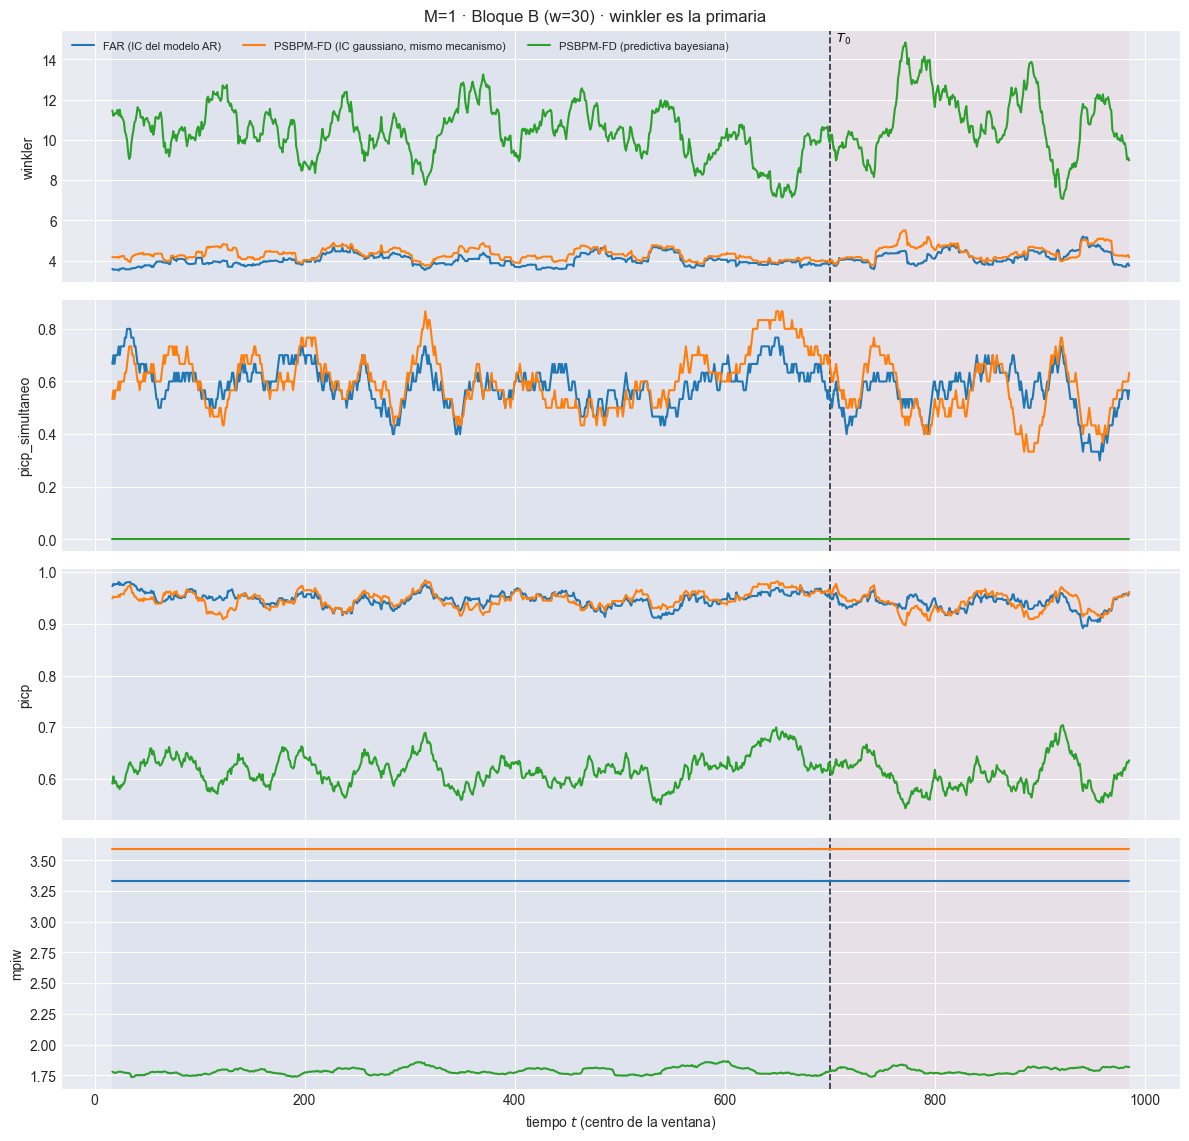

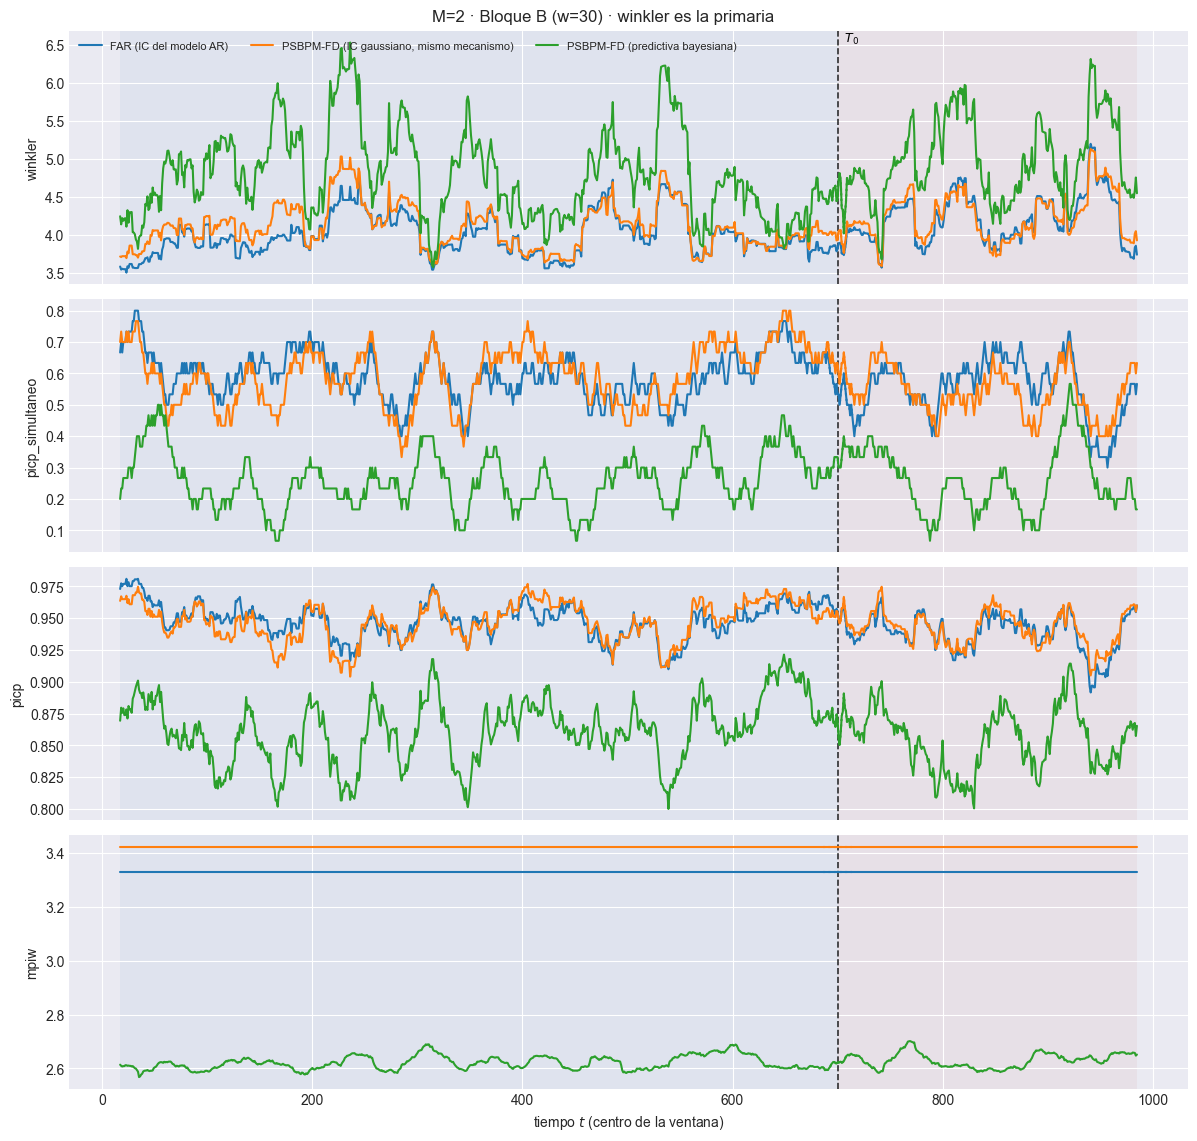

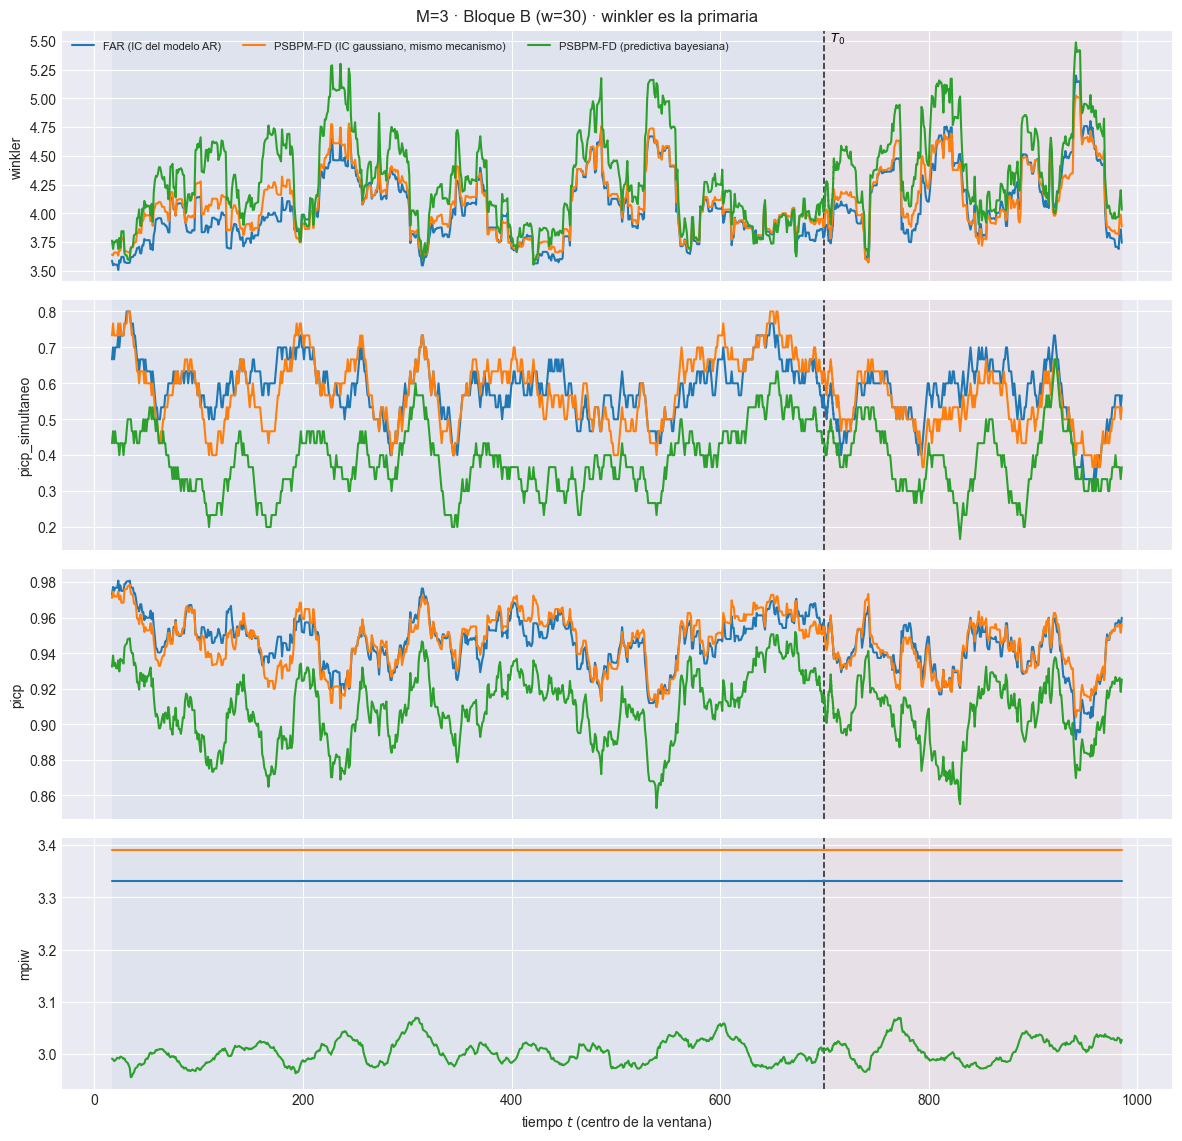

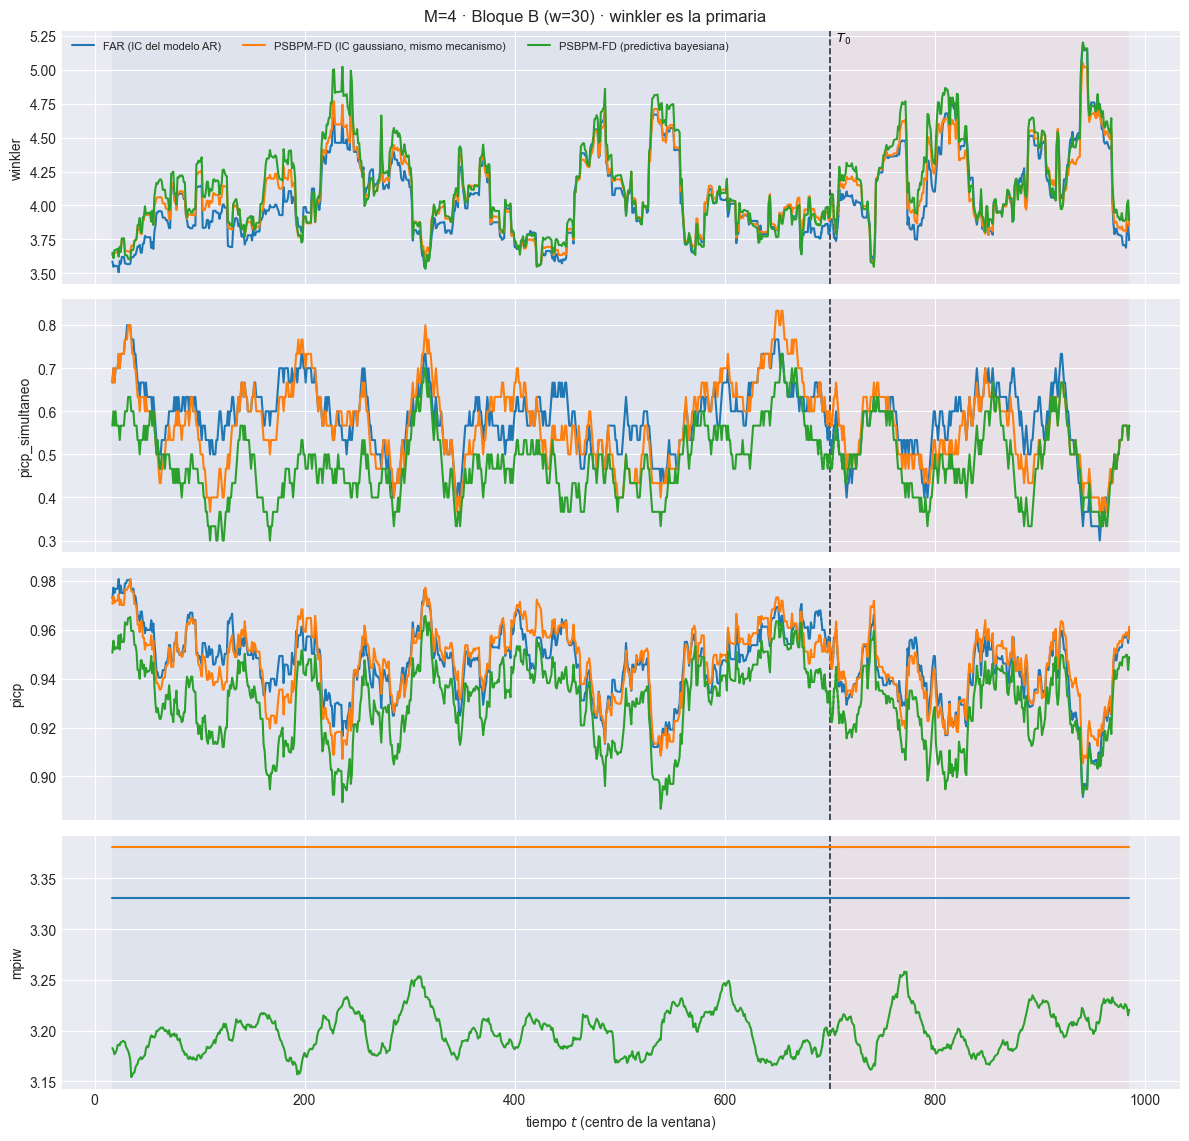

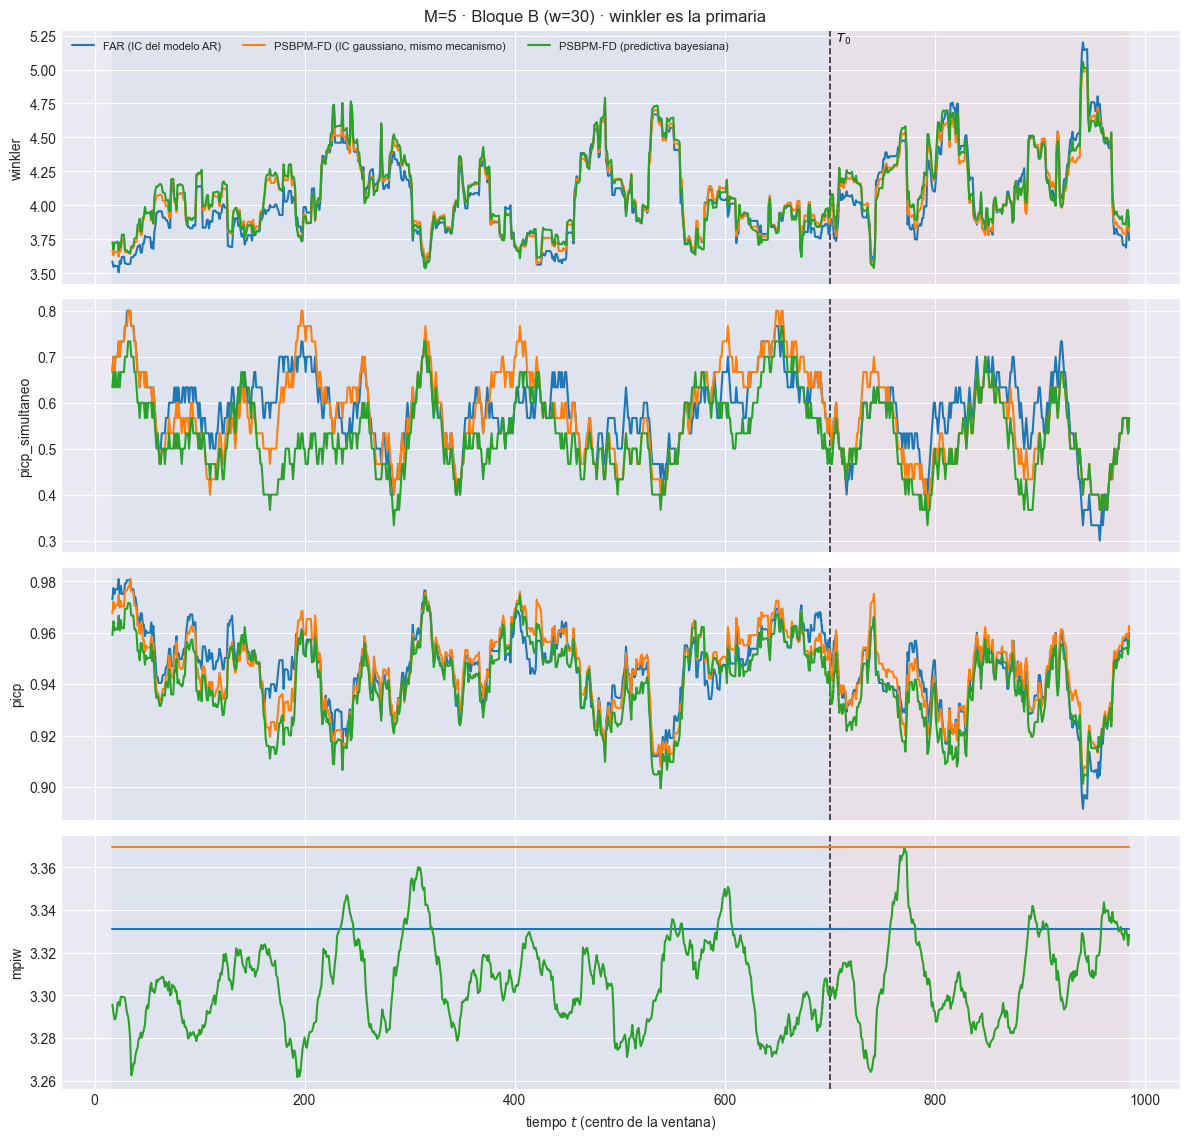

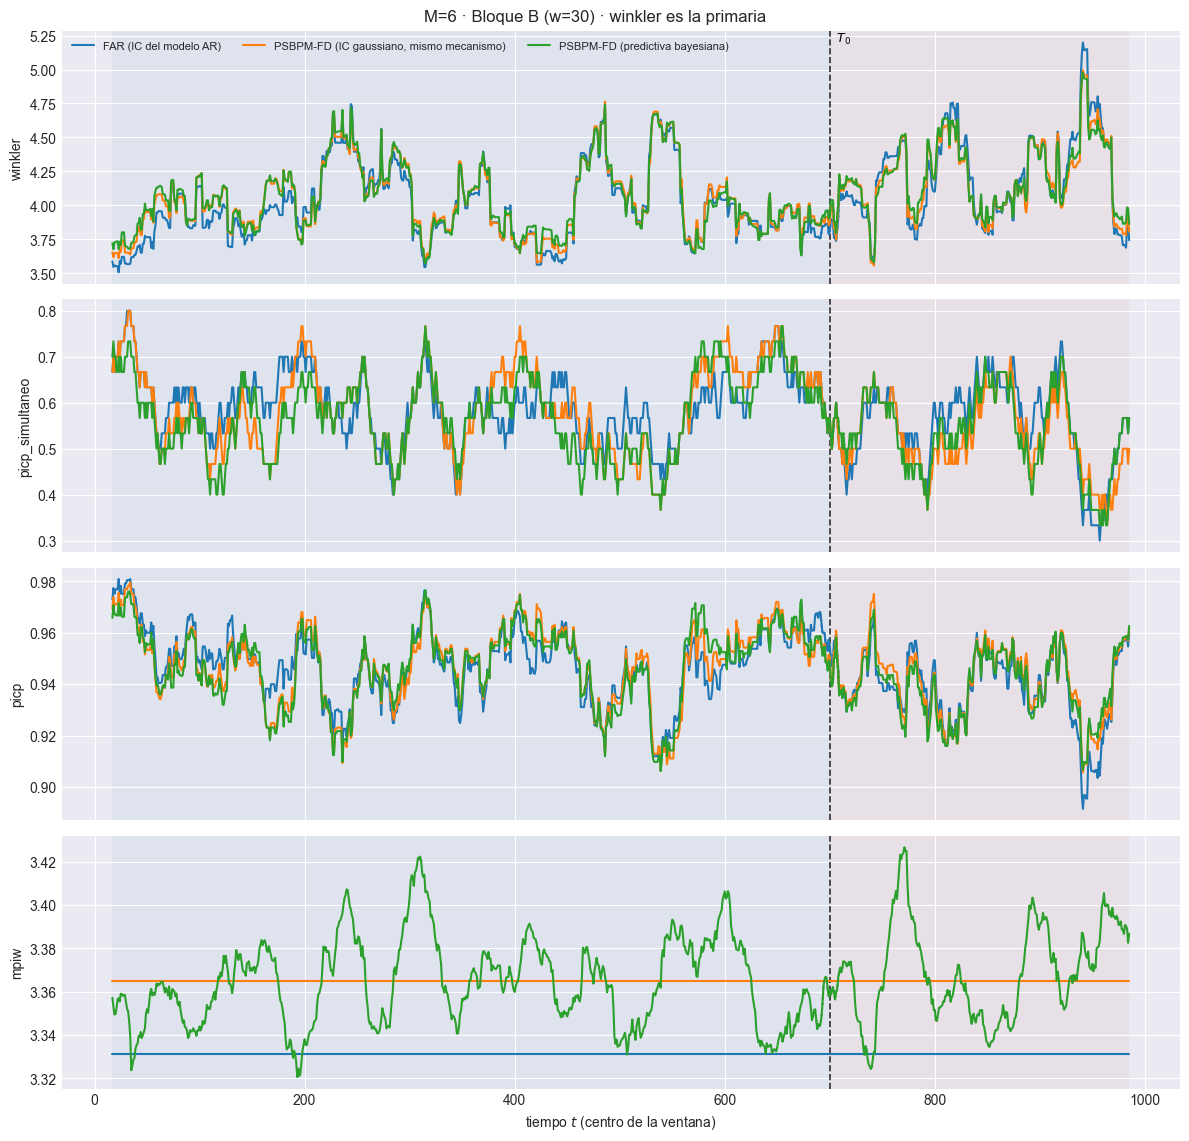

In [19]:
filas_B, VB = [], {}
for M in EST:
    e = EST[M]
    partes = []
    for nombre, ((li, ls), Xp) in BANDAS[M].items():
        t_ = ventana_movil_funcional(X_obj_ev, Xp, grilla, T0_orig, w=W_COMP, li=li, ls=ls,
                                     t_offset=N_LAGS, pesos_tau=PESOS_TAU, nivel=NIVEL_IC,
                                     bloque_A=True, verbose=False)
        t_["banda"] = nombre
        partes.append(t_)
    vb = pd.concat(partes, ignore_index=True)
    vb.attrs["w"] = W_COMP
    vb.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 2}_ventana_bloqueB_w{W_COMP}.csv", index=False)
    VB[M] = vb

    limpio = vb[~vb["cruza_T0"]]
    sub = limpio.dropna(subset=METRICAS_B_COLS)
    tol = 1e-9
    assert (sub["picp_simultaneo"] <= sub["picp"] + tol).all(), f"[M={M}] picp_simultaneo > picp"
    assert (sub["winkler"] <= sub["winkler_max_medio"] + tol).all(), f"[M={M}] winkler > winkler_max_medio"
    assert (sub["winkler_max_medio"] <= sub["winkler_max_glob"] + tol).all(), \
        f"[M={M}] winkler_max_medio > winkler_max_glob"
    filas_B += resumen_ventana(limpio, "banda", METRICAS_B, M)

    plot_ventana_movil(
        vb, T0, ["winkler", "picp_simultaneo", "picp", "mpiw"], columna_grupo="banda",
        title=f"M={M} · Bloque B (w={W_COMP}) · winkler es la primaria",
        save_path=str(e["paths"]["out_report"] / f"{PREFIJO + 2}_ventana_bloqueB_w{W_COMP}.png"),
        verbose=False)
    plt.show()

resumen_B = pd.DataFrame(filas_B)
resumen_B.to_csv(PATH_BARRIDO / f"{PREFIJO + 7}_resumen_bloqueB.csv", index=False)

display(estilo_vista(vista_test(resumen_B, "banda"))
        .set_caption(f"Bloque B · TEST · contra la curva suavizada · sobre las ventanas (w={W_COMP}, "
                     f"sin cruzar T0) · nivel nominal {NIVEL_IC:.0%}"))

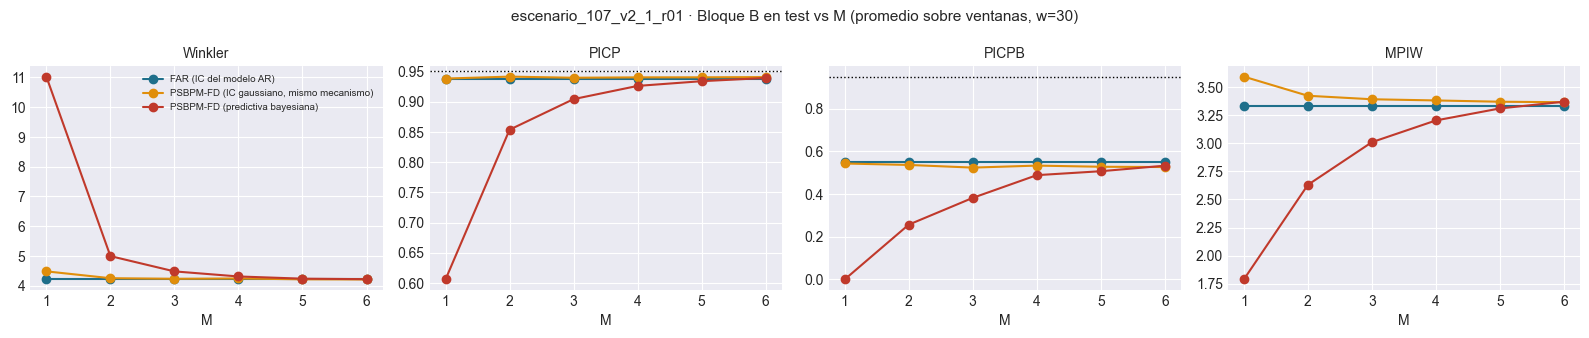

In [20]:
# Barrido en M: winkler, PICP, PICPB y MPIW en test, por banda.
prom = (resumen_B[resumen_B.bloque == "test"]
        .pivot_table(index="M", columns=["columna", "banda"], values="promedio"))
paneles = [("winkler", "Winkler"), ("picp", "PICP"), ("picp_simultaneo", "PICPB"), ("mpiw", "MPIW")]
colores = {G_FAR: "#1f6f8b", G_PSG: "#e08e0b", G_PSB: "#c0392b"}
fig, axes = plt.subplots(1, len(paneles), figsize=(4.0 * len(paneles), 3.4), squeeze=False)
for ax, (col, titulo) in zip(axes[0], paneles):
    for banda, color in colores.items():
        ax.plot(prom.index, prom[(col, banda)], "o-", color=color, label=banda)
    if col.startswith("picp"):
        ax.axhline(NIVEL_IC, color="k", ls=":", lw=1)
    ax.set_xticks(list(prom.index)); ax.set_xlabel("M"); ax.set_title(titulo, fontsize=10)
axes[0][0].legend(fontsize=7)
fig.suptitle(f"{EXPERIMENT_BASE} · Bloque B en test vs M (promedio sobre ventanas, w={W_COMP})", fontsize=11)
fig.tight_layout()
fig.savefig(PATH_BARRIDO / f"{PREFIJO + 7}_bloqueB_vs_M.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Curvas mejor y peor predichas

En $M$ = `M_DETALLE`: los `N_EXTREMOS` orígenes de prueba mejor y peor predichos
por el PSBPM-FD según `METRICA_SEL_IC`, con la banda del FAR y la bayesiana del
PSBPM-FD superpuestas sobre la misma curva.

 mejores: t = [936, 750, 760, 773, 935]
  peores: t = [759, 904, 954, 931, 808]


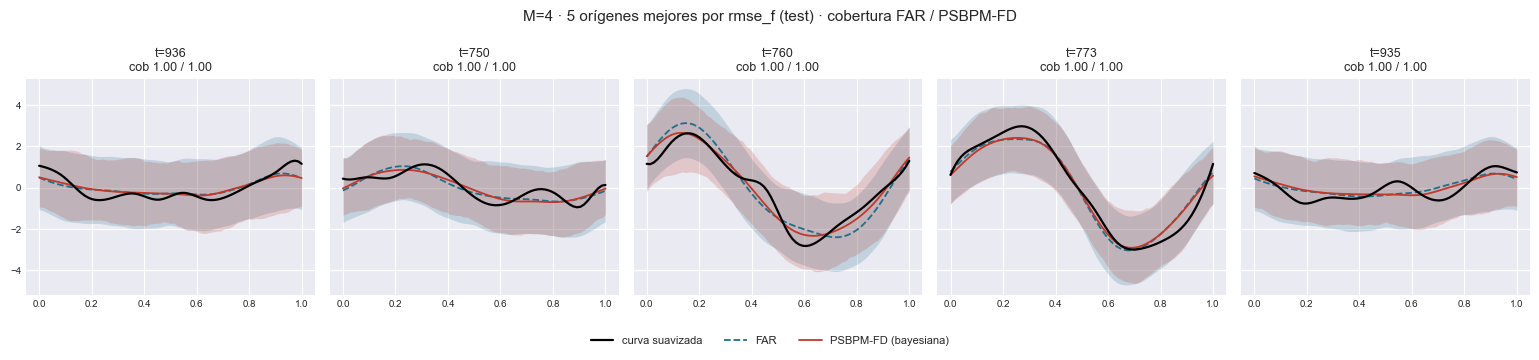

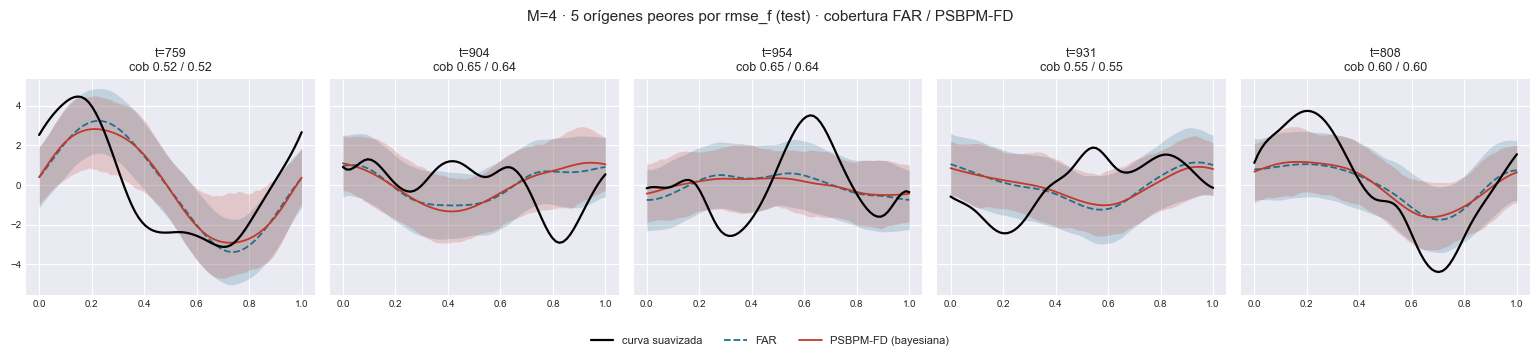

In [21]:
_CLAVE_NORMA = {"mae_f": "l1", "rmse_f": "l2", "linf_medio": "linf"}
assert METRICA_SEL_IC in _CLAVE_NORMA
assert M_DETALLE in EST, f"M_DETALLE={M_DETALLE} no está entre {list(EST)}."

e = EST[M_DETALLE]
serie = normas_error_por_origen(X_obj_ev, e["X_pred_psbp"], grilla, pesos_tau=PESOS_TAU,
                                verificar=False)[_CLAVE_NORMA[METRICA_SEL_IC]]
idx_test = np.where(~es_train)[0]
orden = idx_test[np.argsort(serie[idx_test])]
GRUPOS = {"mejores": orden[:N_EXTREMOS], "peores": orden[-N_EXTREMOS:][::-1]}
for g, idx in GRUPOS.items():
    print(f"{g:>8}: t = {[int(t_orig[i]) for i in idx]}")

(li1, ls1), Xp1 = BANDAS[M_DETALLE][G_FAR]
(li2, ls2), Xp2 = BANDAS[M_DETALLE][G_PSB]

filas_ic = []
for g, idx in GRUPOS.items():
    fig, axes = plt.subplots(1, len(idx), figsize=(3.1 * len(idx), 3.2), sharey=True, squeeze=False)
    for ax, i in zip(axes[0], idx):
        ax.fill_between(grilla, li1[i], ls1[i], color="#1f6f8b", alpha=0.20, lw=0)
        ax.fill_between(grilla, li2[i], ls2[i], color="#c0392b", alpha=0.20, lw=0)
        ax.plot(grilla, Xp1[i], color="#1f6f8b", lw=1.3, ls="--")
        ax.plot(grilla, Xp2[i], color="#c0392b", lw=1.3)
        ax.plot(grilla, X_obj_ev[i], color="k", lw=1.6)
        c1 = (X_obj_ev[i] >= li1[i]) & (X_obj_ev[i] <= ls1[i])
        c2 = (X_obj_ev[i] >= li2[i]) & (X_obj_ev[i] <= ls2[i])
        ax.set_title(f"t={int(t_orig[i])}\ncob {c1.mean():.2f} / {c2.mean():.2f}", fontsize=9)
        ax.tick_params(labelsize=7)
        for nombre, dentro, li, ls in ((G_FAR, c1, li1, ls1), (G_PSB, c2, li2, ls2)):
            filas_ic.append({"grupo": g, "t": int(t_orig[i]), "banda": nombre,
                             f"{METRICA_SEL_IC}_PSBPM": float(serie[i]),
                             "mpiw": float(np.mean(ls[i] - li[i])),
                             "picp_puntual": float(dentro.mean()),
                             "I_t_simultaneo": float(bool(dentro.all()))})
    manijas = [plt.Line2D([], [], color="k", lw=1.6, label="curva suavizada"),
               plt.Line2D([], [], color="#1f6f8b", lw=1.3, ls="--", label="FAR"),
               plt.Line2D([], [], color="#c0392b", lw=1.3, label="PSBPM-FD (bayesiana)")]
    fig.legend(handles=manijas, loc="lower center", ncol=3, fontsize=8, frameon=False,
               bbox_to_anchor=(0.5, -0.10))
    fig.suptitle(f"M={M_DETALLE} · {N_EXTREMOS} orígenes {g} por {METRICA_SEL_IC} (test) · "
                 "cobertura FAR / PSBPM-FD", fontsize=11)
    fig.tight_layout()
    fig.savefig(e["paths"]["out_report"] / f"{PREFIJO + 4}_ic_contraste_{g}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

ic_df = pd.DataFrame(filas_ic).set_index(["grupo", "t", "banda"])
ic_df.to_csv(e["paths"]["out_report"] / f"{PREFIJO + 4}_ic_contraste_origenes.csv")
display(ic_df.style.format({f"{METRICA_SEL_IC}_PSBPM": "{:.4f}", "mpiw": "{:.4f}",
                            "picp_puntual": "{:.3f}", "I_t_simultaneo": "{:.0f}"})
        .set_caption(f"M={M_DETALLE} · ancho y cobertura por origen"))